# Phase 4: Baseline Model

In this phase, I will build a simple baseline model before using a Convolutional Neural Network.

The main goals of this phase are:

- Load the MNIST dataset
- Preprocess the images
- Flatten each 28x28 image into a 1D vector
- Train a simple baseline classifier
- Evaluate the baseline model accuracy
- Use this result as a comparison point for future neural network and CNN models

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
(x_train, y_train) , (x_test, y_test)= mnist.load_data()

In [8]:
x_train_flat= x_train.reshape(x_train.shape[0], -1) / 255.0
x_test_flat = x_test.reshape(x_test.shape[0], -1) / 255.0

In [9]:
print(x_train.shape)
print(x_train_flat.shape)
print(x_test.shape)
print(x_test_flat.shape)
print(x_train_flat.max())
print(x_train_flat.min())

(60000, 28, 28)
(60000, 784)
(10000, 28, 28)
(10000, 784)
1.0
0.0


In [10]:
baseline_model= LogisticRegression(max_iter=1000)
baseline_model.fit(x_train_flat, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [13]:
y_pred=baseline_model.predict(x_test_flat)

In [15]:
baseline_accuracy = accuracy_score(y_test, y_pred)
print(baseline_accuracy)
print(baseline_accuracy * 100)

0.9257
92.57


In [16]:
print("First 10 true labels:")
print(y_test[:10])

print("First 10 predicted labels:")
print(y_pred[:10])

First 10 true labels:
[7 2 1 0 4 1 4 9 5 9]
First 10 predicted labels:
[7 2 1 0 4 1 4 9 6 9]


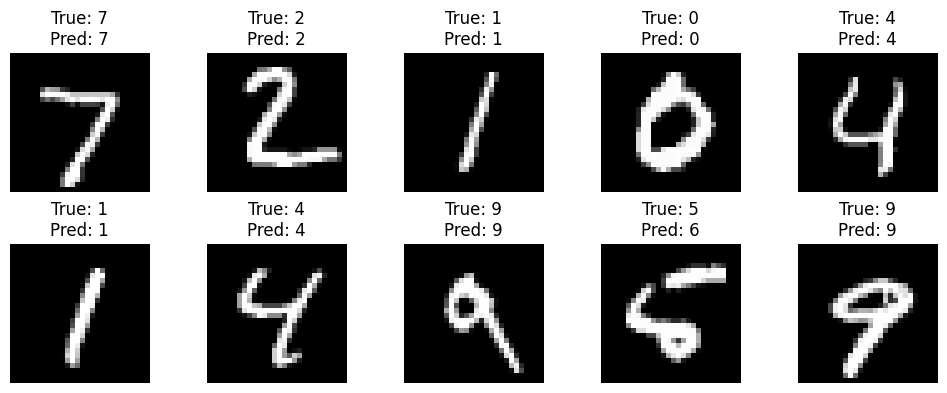

In [17]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"True: {y_test[i]}\nPred: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Baseline Model Predictions

The images above show the first 10 test examples from the MNIST dataset.

For each image:

- `True` represents the correct label from the dataset
- `Pred` represents the label predicted by the Logistic Regression baseline model

This helps visually check whether the baseline model is making correct predictions.

## Baseline Model: Logistic Regression

I used Logistic Regression as a baseline model.

For this model, each 28x28 image was flattened into a 1D vector of 784 pixel values.

The purpose of this baseline model is to create a simple first result before building more advanced neural network and CNN models later.

The baseline accuracy gives me a comparison point. If the CNN performs better than this model, it shows that convolutional layers are useful for image recognition.

## Phase 4 Summary: Baseline Model

In this phase, I built a simple baseline model using Logistic Regression.

### Completed Tasks

- Loaded the MNIST dataset
- Flattened each 28x28 image into a 1D vector of 784 pixel values
- Normalized pixel values from 0–255 to 0–1
- Trained a Logistic Regression baseline model
- Made predictions on the test set
- Calculated the baseline accuracy
- Compared true labels with predicted labels
- Visualized sample predictions

### Key Observation

The Logistic Regression model provides a simple baseline result.  
This result will be used later to compare with more advanced models such as a dense neural network and a Convolutional Neural Network.

If the CNN achieves a higher accuracy than the baseline model, it will show that convolutional layers are better suited for image recognition tasks.